In [1]:
import torch
import torch.nn as nn
from transformers import ViTConfig, ViTModel, ASTConfig, ASTModel
import random  # これを追加
import os
from transformers import get_linear_schedule_with_warmup


In [2]:
from transformers import ViTImageProcessor, ASTFeatureExtractor

# 1. 映像用プロセッサ (ViTの入力形式 224x224, 正規化などを担当)
video_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

# 2. 音声用エキストラクター (ASTのメルスペクトログラム変換を担当)
audio_extractor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes=5
#num_frames = 16 
num_frames = 8
max_duration = 4.0


In [3]:
#%%writefile OrangePiOptimizedTransformer.py
import torch
import torch.nn as nn
from transformers import ViTConfig, ViTModel, ASTConfig, ASTModel

class OrangePiOptimizedTransformer(nn.Module):
    def __init__(self, num_classes=3):
        super(OrangePiOptimizedTransformer, self).__init__()
        
        # 1. 映像: ViT-Base (768次元)
        config_vit = ViTConfig.from_pretrained("google/vit-base-patch16-224-in21k")
        self.image_model = ViTModel(config_vit)
        
        # 2. 音声: AST (768次元)
        config_ast = ASTConfig.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
        config_ast.num_hidden_layers = 4
        self.audio_model = ASTModel(config_ast)
        
        # ★ここを必ず 768 にしてください
        #embed_dim = 768 
        # 2. 自動的に次元数を取得 (Baseなら768, Tinyなら192が自動で入る)
        embed_dim = self.image_model.config.hidden_size 

        # 3. 結合層にはこの embed_dim を使う
        self.fusion = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=8, 
            batch_first=True,
            #activation="relu" # GELUよりRKNNと相性が良い add by nishi 2026.4.5 for rknn
        )
        self.classifier = nn.Linear(embed_dim * 2, num_classes)

        # ★ここを追加：音声用の強めのDropout  audio だけ、dropout を試す。 by nishi 2026.4.4
        #self.audio_dropout = nn.Dropout(0.5)
        self.audio_dropout = nn.Dropout(0.7)
        
        # --- __init__ の中に追加 ---　add by nishi 2026.4.4
        # オリジナルの classifier と同じクラス数で、入力が 768 のものを用意
        self.monitor_classifier = nn.Linear(768, num_classes) 
    
    # こちらは、5 次元 [Batch, 16, 3, 224, 224] です。
    # --- forward の修正 ---
    def forward(self, pixel_values, input_values):
        # 入力の形状: [Batch, num_frames, 3, 224, 224]
        batch_size, num_frames, channels, height, width = pixel_values.shape
        
        # 映像処理
        # バッチとフレームを混ぜて一気にViTへ
        # 映像 [Batch*Frames, 3, 224, 224] -> [Batch*Frames, 768]
        pixel_values = pixel_values.view(-1, channels, height, width) 
        img_features = self.image_model(pixel_values).last_hidden_state[:, 0, :] 

        # 元のバッチサイズとフレーム数に戻して平均をとる
        # これにより num_frames がいくつであっても [Batch, 768] に集約される
        # フレーム平均 [Batch, 768]
        video_feats = img_features.view(batch_size, num_frames, -1).mean(dim=1)
    
        # 音声 [Batch, 768]
        audio_feats = self.audio_model(input_values).last_hidden_state[:, 0, :]

        # ★ここを追加：音声特徴量に Dropout をかける audio 側だけ、dropout add by nishi 2026.4.4
        audio_feats = self.audio_dropout(audio_feats)
        
        # --- 個別の判定（モニタリング用） ---
        # self.classifier ではなく、768次元用の monitor_classifier を使う
        video_logits = self.monitor_classifier(video_feats)
        audio_logits = self.monitor_classifier(audio_feats)
    
        # --- 統合判定（オリジナル通り） ---
        # 結合 (768 と 768 なので重なるようになります)
        #combined = torch.stack([img_out, aud_out], dim=1) # 以前の img_out = video_feats です
        combined = torch.stack([video_feats, audio_feats], dim=1) # 以前の img_out = video_feats です
        fused = self.fusion(combined)
        out = fused.view(fused.size(0), -1)
        
        combined_logits = self.classifier(out) # 1536次元用
    
        # 3つの判定結果を返す
        return combined_logits, video_logits, audio_logits



転移学習のコツ:  
初期の数エポックはバックボーン(image_model/audio_model)をフリーズし、  
結合部(classifier)のみを学習させると安定します。  


In [4]:
# --- 使用イメージ ---
model = OrangePiOptimizedTransformer(num_classes=num_classes)
model.to(device)
print('OK')

OK


1. データセットの準備 (Datasetクラス)  
mp4から「4枚のフレーム」と「3秒間の音声」を同期させて抽出するクラスです。   
  
1. do_rescale=True (再スケーリング)  
画像データは通常、1ピクセルが 0（黒）から 255（白）の整数で表されています。これを 0.0 から 1.0 の範囲の小数 に割り算（÷ 255）して変換します。  
  
    理由: 数値が大きすぎるとAIの計算が不安定になるため、1以下の小さな数字に揃えます。  
  
2. do_normalize=True (正規化)  
0.0〜1.0 になった数値を、さらにモデル（ViT）が学習した時と同じ 「平均」と「標準偏差」 を使ってずらします。  
  
    具体的には (数値 - 平均) ÷ 標準偏差 という計算をします。  
    理由: ViTが世界中の画像で学習したときの「色の基準」に合わせるためです。これを行わないと、AIにとって「色が不自然」に見えてしまい、正しく判定できなくなります。  
  
まとめ：なぜこれらが必要か？  
自作の関数 resize_with_padding で「形」は整えましたが、「色の数値」 はまだ 0〜255 のままです。  
  
    do_resize=False: 形は自分で整えたから、プロセッサはリサイズしなくていいよ。  
    do_rescale=True: でも、0〜1.0の小数には直してね。  
    do_normalize=True: そして、ViT専用の色バランスに調整してね。  



In [5]:
import cv2
#import librosa
import torch
from torch.utils.data import Dataset
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
import numpy as np
from moviepy import VideoFileClip

def resize_with_padding(image, target_size=(224, 224)):
    h, w = image.shape[:2]
    scale = min(target_size[0] / h, target_size[1] / w)
    new_w, new_h = int(w * scale), int(h * scale)
    
    # リサイズ
    resized = cv2.resize(image, (new_w, new_h))
    
    # 黒埋め用のキャンバス作成
    canvas = np.zeros((target_size[0], target_size[1], 3), dtype=np.uint8)
    
    # 中央に配置
    offset_y = (target_size[0] - new_h) // 2
    offset_x = (target_size[1] - new_w) // 2
    canvas[offset_y:offset_y+new_h, offset_x:offset_x+new_w] = resized
    
    return canvas

# 赤外線カメラみたいなフィルター
def apply_infrared_effect(image):
    # 1. グレースケール化（色情報を抜く）
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # 2. 緑色の色調を強くする (Gチャンネルにグレースケールを割り当てる)
    # [H, W, 3] の 0埋め配列を作り、緑(1番目)のチャンネルにだけ値を入れる
    ir_image = np.zeros_like(image)
    ir_image[:, :, 1] = gray  # 緑チャンネル
    ir_image[:, :, 0] = (gray * 0.1).astype(np.uint8) # わずかに赤
    ir_image[:, :, 2] = (gray * 0.1).astype(np.uint8) # わずかに青
    
    # 3. ノイズを加える（ザラザラ感）
    noise = np.random.randint(0, 20, (image.shape[0], image.shape[1]), dtype=np.uint8)
    ir_image[:, :, 1] = cv2.add(ir_image[:, :, 1], noise)
    
    return ir_image

# 夜間用フィルター
def apply_night_vision(image):
    # 1. モノクロ化（色の依存をなくす）
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # 2. 輝度とコントラストの調整（夜間っぽく少し暗く、コントラストを強めに）
    # alpha: コントラスト(1.0-1.5), beta: 明るさ(-20-0)
    alpha = random.uniform(1.0, 1.3)
    beta = random.randint(-30, -10)
    gray = cv2.convertScaleAbs(gray, alpha=alpha, beta=beta)

    # 3. 緑がかった色調にする（一般的な赤外線カメラのイメージ）
    # R:10%, G:100%, B:10% くらいにして、緑をメインにする
    nv_image = np.stack([
        (gray * 0.1).astype(np.uint8), # R
        gray,                          # G
        (gray * 0.1).astype(np.uint8)  # B
    ], axis=-1)

    # 4. 粒子ノイズ（ザラザラ感）を追加
    noise = np.random.normal(0, 15, gray.shape).astype(np.int16)
    nv_image[:, :, 1] = np.clip(nv_image[:, :, 1].astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return nv_image

class VideoAudioDataset(Dataset):
    def __init__(self, mp4_files, labels, video_processor, audio_extractor, num_frames=4, train=True, max_duration = 4.0):
        self.mp4_files = mp4_files
        self.labels = labels
        self.video_processor = video_processor
        self.audio_extractor = audio_extractor
        self.num_frames = num_frames
        self.train = train # 学習時のみ拡張を適用するためのフラグ
        self.max_duration = max_duration  # add by nishi 2026.4.5
        self.target_len = int(self.max_duration) * 16000      # add by nishi 2026.4.5
    
    def __len__(self):
        return len(self.mp4_files)

    def __getitem__(self, idx):
        path = self.mp4_files[idx]
        cap = cv2.VideoCapture(path)
        fps = cap.get(cv2.CAP_PROP_FPS) # 1秒あたりのフレーム数
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # --- 映像も「最初の4秒」に限定する ---
        #max_duration = 4.0
        # 4秒分、または動画全体の短い方のフレーム数をターゲットにする
        end_frame = min(total_frames, int(self.max_duration * fps))
        
        # 0フレームから3秒地点（end_frame）の間で16枚抜く
        indices = np.linspace(0, end_frame - 1, self.num_frames).astype(int)
       
        # 左右反転フラグ（学習時のみランダムに決定）
        do_flip = self.train and (random.random() > 0.5)
        # 赤外線フィルター適用
        do_ir = self.train and (random.random() > 0.7) # 30%の確率
        # 夜間フィルター
        #do_night_mode = self.train and (random.random() > 0.5) # 50%の確率で夜間モード
        do_night_mode = self.train and (random.random() > 0.7) # 30%の確率で夜間モード
        
        frames = []
        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                # 1. アスペクト比維持リサイズ
                frame = resize_with_padding(frame)
                if False:
                    # 赤外線フィルター適用
                    if do_ir:
                        frame = apply_infrared_effect(frame)
                    # 夜間フィルターの適用
                    if do_night_mode:
                        frame = apply_night_vision(frame)
                # 2. データ拡張（左右反転）
                if do_flip:
                    frame = cv2.flip(frame, 1)
                frames.append(frame)
            else:
                frames.append(np.zeros((224, 224, 3), dtype=np.uint8))
        cap.release()
        
        # 既に 224x224 になっているので、processorではリサイズせず正規化のみ行う
        #pixel_values = self.video_processor(images=frames, return_tensors="pt", do_resize=False).pixel_values

        # Dataset内で pixel_values を作る際、do_resize=False を指定します
        pixel_values = self.video_processor(
            images=frames, 
            return_tensors="pt", 
            do_resize=False,       # これが重要！ video_processor 側へ通知!! 形は自分で整えたから、プロセッサはリサイズしなくていいよ。
            do_rescale=True, 
            do_normalize=True
        ).pixel_values

        # --- 2. 音声抽出 (ここが NameError の原因でした) ---
        try:
            with VideoFileClip(path) as video:
                #duration = min(video.duration, 3.0)
                duration = min(video.duration, self.max_duration)  # changed by nishi 2026.4.5
                audio_clip = video.audio.subclipped(0, duration)
                y = audio_clip.to_soundarray(fps=16000)
                if len(y.shape) > 1:
                    y = y.mean(axis=1)
                
                target_len = self.target_len
                if len(y) < target_len:
                    y = np.pad(y, (0, target_len - len(y)))
                else:
                    y = y[:target_len]
        except:
            # 音声がない等のエラー時は無音を作成
            #y = np.zeros(48000)
            y = np.zeros(self.target_len)   # changed by nishi 2026.4.5

        # ここで 'input_values' を確実に定義します
        input_values = self.audio_extractor(y, sampling_rate=16000, return_tensors="pt").input_values.squeeze(0)

        return pixel_values, input_values, torch.tensor(self.labels[idx])


1. 推奨されるフォルダ構成  
まず、PC内のデータを以下のように整理すると管理しやすくなります。  
text  
  
dataset/  
  ├── alert/          (クラス0)  
  │    ├── dog01.mp4  
  │    └── dog02.mp4  
  ├── hungry/     (クラス1)  
  │    ├── dog03.mp4  
  │    └── dog04.mp4  
  ├── miss/     (クラス2)  
  │    ├── dog03.mp4  
  │    └── dog04.mp4  
  ├── long_time_no_see/     (クラス3)  
  │    ├── dog03.mp4  
  │    └── dog04.mp4  
  └── background/        (クラス4)  
       ├── dog05.mp4  
       └── dog06.mp4  

注) CPU が、av1に対応していない場合、 h264　の mp4 を使ってください。  


In [6]:
#2. ファイルリストの作成と DataLoader への投入
#以下のコードで、フォルダから自動的にパスとラベルを読み取り、学習を開始できる状態にします。

import glob
import os
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# --- 1. ファイルパスとラベルのリストを作成 ---
data_dir = "dataset_h264/"
classes = ["alert", "hungry", "miss", "log_time_no_see", "background"] # フォルダ名と一致させる
file_paths = []
labels = []

for i, class_name in enumerate(classes):
    # 各フォルダ内の .mp4 ファイルを取得
    path_pattern = os.path.join(data_dir, class_name, "*.mp4")
    files = glob.glob(path_pattern)
    
    file_paths.extend(files)
    labels.extend([i] * len(files)) # クラス番号(0, 1, 2,3)を割り当て

# --- 2. 学習用と検証用に分割 (8:2) ---
train_files, val_files, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

# --- 3. Dataset のインスタンス化 ---
# 前述の VideoAudioDataset クラスを使用
train_dataset = VideoAudioDataset(
    train_files, train_labels, video_processor, audio_extractor,num_frames=num_frames, max_duration = max_duration
)
val_dataset = VideoAudioDataset(
    val_files, val_labels, video_processor, audio_extractor,num_frames=num_frames , max_duration = max_duration
)

batch_size=4
#batch_size=2


# --- 4. DataLoader の作成 ---
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,   # 動画+音はメモリを食うので、まずは小さめ(2〜4)から
    shuffle=True,   # 学習データはシャッフル必須
    num_workers=2,   # 並列読み込み数（Windowsなら0にするのが無難な場合も）
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False
)

print(f"学習データ数: {len(train_dataset)}, 検証データ数: {len(val_dataset)}")

学習データ数: 32, 検証データ数: 9


In [7]:
#model.to(device)

# 下記、ワーニングの抑制!!  --> 効果ない
# [av1 @ 0x4182d400] Your platform doesn't support hardware accelerated AV1 decoding.
#[av1 @ 0x4182d400] Failed to get pixel format.
#import os
# ffmpegやOpenCVのログレベルを下げて警告を非表示にする
#os.environ["OPENCV_LOG_LEVEL"] = "SILENT"
#os.environ["AV_LOG_FORCE_NOCOLOR"] = "1"

if True:
    # 1バッチ分を取り出すテスト
    try:
        # DataLoaderから最初のバッチを取得
        batch = next(iter(train_loader))
        pixel_values, input_values, labels = batch
    
        print("--- データ形状の確認 ---")
        # ここを5次元対応に修正
        b, f, c, h, w = pixel_values.shape
        print(f"画像バッチ: {pixel_values.shape} (Batch:{b}, Frames:{f}, C:{c}, H:{h}, W:{w})")
        
        print(f"音声バッチ: {input_values.shape}") 
        print(f"ラベル: {labels.shape}") 
    
        # 実際にモデルに流してみるテスト
        model.to(device)
        model.eval()
        with torch.no_grad():
            # モデルのforwardを先ほど修正した5次元対応版に書き換えてから実行してください
            outputs, video_out, audio_out = model(pixel_values.to(device), input_values.to(device))
            print(f"\nモデル出力の形状: {outputs.shape}")
            
        print("\n✅ テスト成功！4フレーム統合モデルが正常に動作しました。")
    
    except Exception as e:
        print(f"\n❌ エラーが発生しました:\n{e}")



--- データ形状の確認 ---
画像バッチ: torch.Size([4, 8, 3, 224, 224]) (Batch:4, Frames:8, C:3, H:224, W:224)
音声バッチ: torch.Size([4, 1024, 128])
ラベル: torch.Size([4])

モデル出力の形状: torch.Size([4, 5])

✅ テスト成功！4フレーム統合モデルが正常に動作しました。


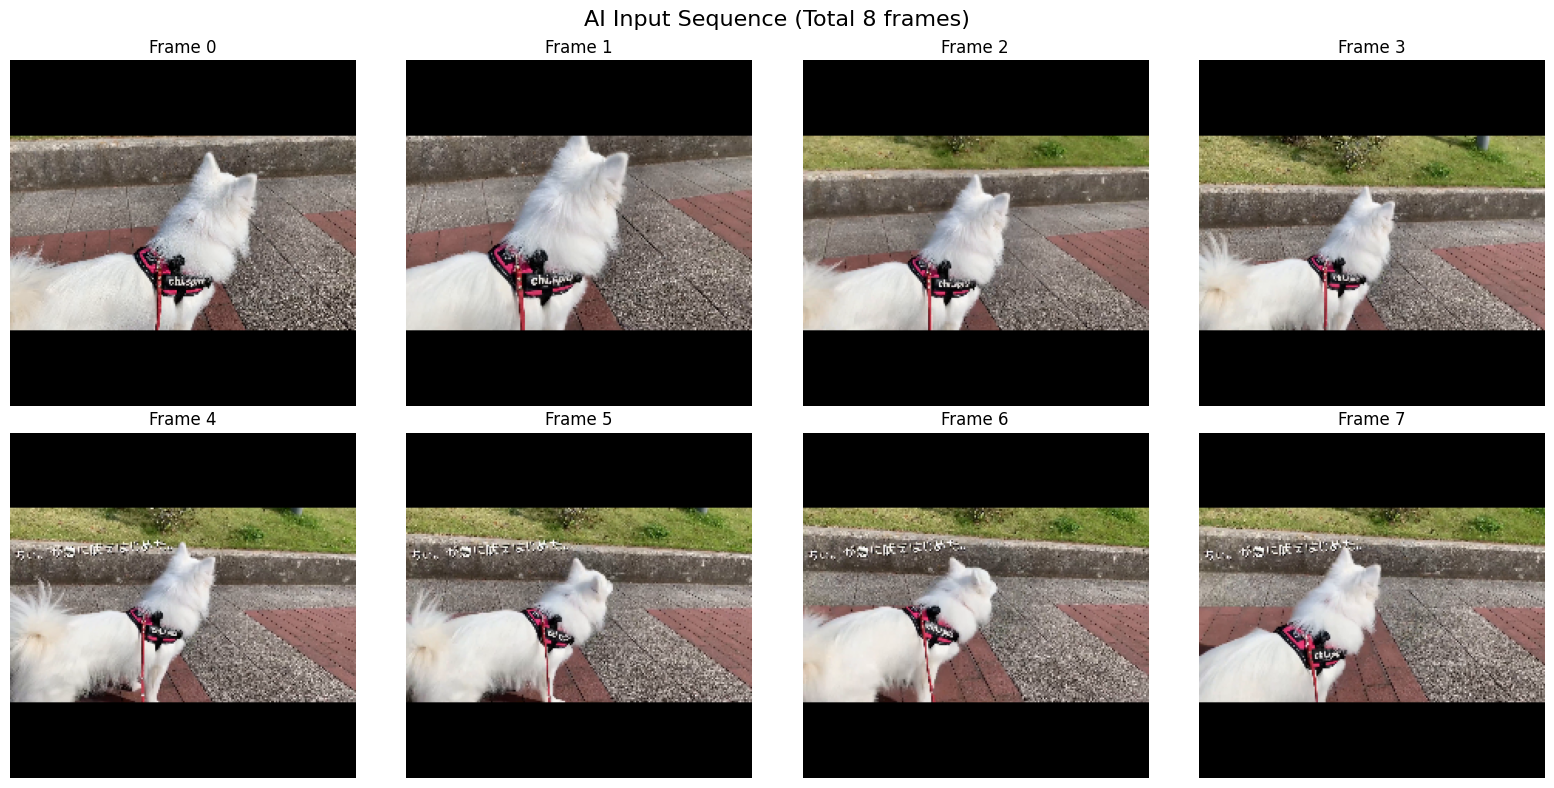

In [8]:
import matplotlib.pyplot as plt
import numpy as np

if False:
    # 1バッチ取得
    batch = next(iter(train_loader))
    pixel_values, _, _ = batch
    
    # [Batch, Frames, C, H, W] なので、最初のバッチの最初のフレームを取り出す
    img_tensor = pixel_values[0, 0] 
    
    # 表示用に整形 (C,H,W -> H,W,C)
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    
    # 正規化を解除して 0-1 に戻す（簡易版）
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    
    plt.imshow(img_np)
    plt.title("What AI is looking at (Padded)")
    plt.axis('off')
    plt.show()

# 1バッチ取得
batch = next(iter(train_loader))
pixel_values, _, _ = batch 
video_data = pixel_values[0] # 最初の動画 [Frames, C, H, W]
total_frames = video_data.shape[0]

# 8フレーム分を均等に抽出
num_display = 8
indices = np.linspace(0, total_frames - 1, num_display, dtype=int)

# 2行4列で表示
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f"AI Input Sequence (Total {total_frames} frames)", fontsize=16)

for i, idx in enumerate(indices):
    ax = axes[i // 4, i % 4]
    img_tensor = video_data[idx]
    
    # 整形と正規化解除
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_min, img_max = img_np.min(), img_np.max()
    if img_max - img_min > 0:
        img_np = (img_np - img_min) / (img_max - img_min)
        
    ax.imshow(img_np)
    ax.set_title(f"Frame {idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()


Index: 0, Label Index: 0, Name: alert


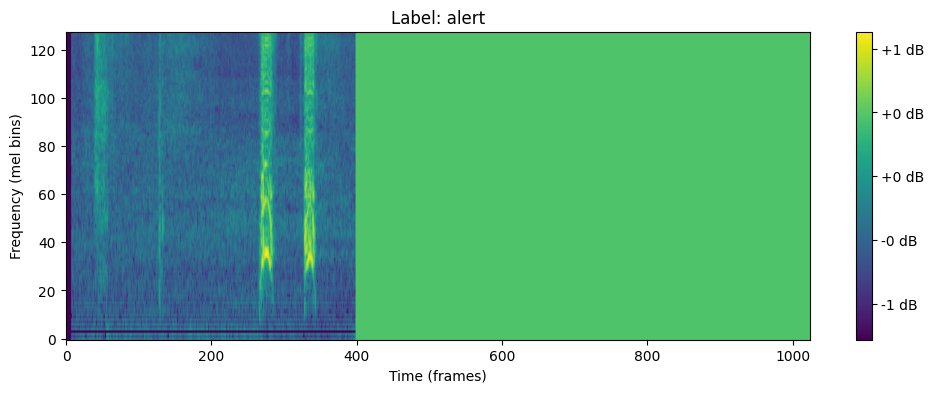

In [14]:
import matplotlib.pyplot as plt

def show_mel_spectrogram(input_values, title="Mel Spectrogram"):
    # input_values は [batch, time, freq] なので [1024, 128] を取り出す
    if len(input_values.shape) == 3:
        spec = input_values[0]
    else:
        spec = input_values

    # ASTの入力は [Time, Freq] なので、表示用に転置して [Freq, Time] にする
    spec_to_show = spec.T
    
    plt.figure(figsize=(12, 4))
    # origin='lower' で低音を下にする
    plt.imshow(spec_to_show, aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.xlabel('Time (frames)')
    plt.ylabel('Frequency (mel bins)')
    plt.show()

# --- 使用例 (Datasetのループ内などで) ---
# sample = train_dataset[0]

# 1. バッチからデータを取り出す
pixel_values, input_values, labels = batch

# 2. 最初のデータの情報を取得
idx = 0
current_label_idx = labels[idx].item()  # Tensorから数値を取り出す
current_label_name = classes[current_label_idx]

print(f"Index: {idx}, Label Index: {current_label_idx}, Name: {current_label_name}")

# 3. スペクトログラムを表示
# input_values[idx] は (1024, 128) の形状を想定
show_mel_spectrogram(input_values[idx].numpy(), title=f"Label: {current_label_name}")


In [ ]:
#2. 学習ループの実装
#マルチモーダルモデルの学習は、片方のモダリティ（例：音だけ）に依存しすぎないよう、Dropoutや学習率の調整が重要です。

# 設定
#num_epochs = 1 # 基本の学習率
#num_epochs = 50 # 基本の学習率
#num_epochs = 100 # 1000は多すぎる可能性が高いです（過学習の懸念）
num_epochs = 200 # 1000は多すぎる可能性が高いです（過学習の懸念）

#base_lr = 1e-4
#base_lr = 5e-5  # 1e-4 の半分に設定
base_lr = 1e-5  # 1e-4 の半分に設定

total_steps = len(train_loader) * num_epochs
warmup_steps = int(total_steps * 0.1) # 最初の10%（5エポック分）で徐々に上げる

criterion = nn.CrossEntropyLoss() # 分類用

#2. 学習率スケジューラーの設定
#1000回（1000エポック）回す場合、ずっと同じ学習率だと「正解の周りをウロウロするだけ」で収束しません。CosineAnnealingLR を使うと、学習率を滑らかな曲線（コサイン波）で下げていき、後半でじっくりと微調整ができます。

from torch.optim.lr_scheduler import CosineAnnealingLR

USE_FINE_TUNE=True
if USE_FINE_TUNE:
    # ファインチューニングの場合は、下記。 add by nishi 2026.4.4 
    # 各セクションで「学習を許可した（True）パラメータ」だけを抽出する
    optimizer = torch.optim.AdamW([
        {
            'params': filter(lambda p: p.requires_grad, model.image_model.parameters()), 
            'lr': base_lr
        },
        {
            'params': filter(lambda p: p.requires_grad, model.audio_model.parameters()), 
            'lr': base_lr * 0.1
        },
        {
            'params': filter(lambda p: p.requires_grad, model.fusion.parameters()), 
            'lr': base_lr
        },
        {
            'params': filter(lambda p: p.requires_grad, model.classifier.parameters()), 
            'lr': base_lr
        },
        {
            'params': filter(lambda p: p.requires_grad, model.monitor_classifier.parameters()), 
            'lr': base_lr
        }
    ], lr=base_lr, weight_decay=0.01)

else:
    optimizer = torch.optim.AdamW([
        {'params': model.image_model.parameters(), 'lr': base_lr},
        {'params': model.audio_model.parameters(), 'lr': base_lr * 0.1}, # 音声はさらに慎重に 5e-6
        {'params': model.fusion.parameters(), 'lr': base_lr},
        {'params': model.classifier.parameters(), 'lr': base_lr},
        {'params': model.monitor_classifier.parameters(), 'lr': base_lr}
    ], lr=base_lr, weight_decay=0.01)

#optimizer = torch.optim.AdamW([
#    {'params': model.image_model.parameters(), 'lr': base_lr},       # 映像はフルで学習
#    {'params': model.audio_model.parameters(), 'lr': base_lr * 0.1}, # 音声は控えめ(1/10)
#    {'params': model.fusion.parameters(), 'lr': base_lr},            # 統合層
#    {'params': model.classifier.parameters(), 'lr': base_lr},        # 判定器
#    {'params': model.monitor_classifier.parameters(), 'lr': base_lr} # モニタリング用
#], lr=base_lr)


# 100エポックかけて学習率を 1/100 まで下げるスケジューラー
#scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
#scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

# スケジューラ warmup を、組み込む
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=warmup_steps, 
    num_training_steps=total_steps
)


#2. train_epoch の修正（scheduler.stepを追加）
def train_epoch(model, dataloader, optimizer, scheduler, criterion):
    model.train()
    total_loss, video_loss, audio_loss = 0, 0, 0
    
    for pixels, audios, labels in dataloader:
        pixels, audios, labels = pixels.to(device), audios.to(device), labels.to(device)
        optimizer.zero_grad()

        #outputs = model(pixels, audios)
        # 3つの出力を受け取る（モデルのforwardを修正済み前提）
        combined_out, video_out, audio_out = model(pixels, audios)

        # 全てのLossを計算
        loss_comb = criterion(combined_out, labels)
        loss_vid = criterion(video_out, labels)
        loss_aud = criterion(audio_out, labels)

        # 学習自体は「統合Loss」で行う
        loss_comb.backward()
        optimizer.step()
        scheduler.step() # ★ここで学習率を更新

        total_loss += loss_comb.item()
        video_loss += loss_vid.item()
        audio_loss += loss_aud.item()
    # 平均の計算
    n = len(dataloader)
    return total_loss/n, video_loss/n, audio_loss/n


In [ ]:
if not USE_FINE_TUNE:
    # こちらは、転移学習用の設定です。
    # 最初はバックボーン（既存モデル部分）を固める（勾配計算をオフにする）
    for param in model.image_model.parameters():
        param.requires_grad = False
        
    for param in model.audio_model.parameters():
        param.requires_grad = False
    
    print("バックボーンの重みを固定しました。結合層と分類層のみ学習します。")

else:
    # こちらは、ファインチューニング用の設定です。
    #1. レイヤーを指定して解凍するコード
    # --- 全体を一旦フリーズ ---
    for param in model.parameters():
        param.requires_grad = False
    
    # --- 映像 (ViT): 12層のうち、後ろの 10 と 11 を解凍 ---
    for name, param in model.image_model.named_parameters():
        if "encoder.layer.10" in name or "encoder.layer.11" in name or "layernorm" in name or "pooler" in name:
            param.requires_grad = True
    
    # --- 音声 (AST): 4層のうち、後ろの 2 と 3 を解凍 ---
    for name, param in model.audio_model.named_parameters():
        if "encoder.layer.2" in name or "encoder.layer.3" in name or "layernorm" in name:
            param.requires_grad = True
    
    # --- 結合層・判定器: ここは常に学習させる ---
    for param in model.fusion.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True
    for param in model.monitor_classifier.parameters():
        param.requires_grad = True



In [ ]:
#1. 検証用データの評価関数 (evaluate_model)
#この関数は、学習に使っていないデータで「正解率（Accuracy）」を計算します。ポイントは、推論モード（model.eval()）に切り替えて、
# Dropoutなどのランダムな挙動を止めることです。

def evaluate_model(model, dataloader, device):
    model.eval()  # 推論モード（重要！）
    correct = 0
    total = 0
    
    with torch.no_grad(): # 勾配計算をオフにしてメモリ節約
        for pixels, audios, labels in dataloader:
            pixels, audios, labels = pixels.to(device), audios.to(device), labels.to(device)
            
            #outputs = model(pixels, audios)
            # 3つの出力を受け取る（モデルのforwardを修正済み前提）
            outputs, video_out, audio_out = model(pixels, audios)
            _, predicted = torch.max(outputs.data, 1) # 最も高い確率のクラスを選択
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy


In [ ]:
#「ロス関数に重みをつける（Class Weight）」具体的な書き方はあるの?
#
#はい、あります。特に「嘔吐」のように発生頻度が低い（データ数が少ない）クラスを学習させる場合、この
#「重み付き損失関数（Weighted Cross Entropy）」は必須と言えるテクニックです。
#やり方は簡単で、nn.CrossEntropyLoss を作成する際に、各クラスの重要度を weight 引数として渡すだけです。
#1. 具体的な実装コード
#例えば、クラスが [0: 正常(100件), 1: 咳(30件), 2: 嘔吐(10件)] という偏ったデータセットの場合の実装例です。

import torch
import torch.nn as nn

# クラスごとの重みを計算（基本は「データ数の逆数」に近い比率にします）
# データが少ないクラスほど、重みを大きく設定します。
# 例：正常を 1.0 としたとき、咳を 3.0、嘔吐を 10.0 に設定
weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0], dtype=torch.float)
#weights = torch.tensor([1.0, 3.0, 10.0, 1.0], dtype=torch.float)

# GPUを使っている場合は、重みもGPUに送る必要があります
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = weights.to(device)

# 重み付きの損失関数を定義
criterion = nn.CrossEntropyLoss(weight=weights)

# --- あとは通常通り学習ループで使うだけ ---
# loss = criterion(outputs, labels) 


In [ ]:
best_acc = 0.0

#3. 全体を統合した「壊れない」学習ループ
#ここでさらに、Early Stopping（早期終了）の概念も少し加え、精度が上がらなくなったら途中で止める工夫を入れると完璧です。
#python

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model.to(device)

best_acc = 0.0
patience = 20  # 20エポック連続で更新されなければ終了
counter = 0

loss_best=1000.0

min_loss=0.3

out_dir="output"
# 出力先のクラスフォルダを作成
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

best_acc_path = os.path.join(out_dir, "best_acc_multimodal_model.pth")
best_loss_path = os.path.join(out_dir, "best_loss_multimodal_model.pth")

for epoch in range(num_epochs):
    # 1. 学習
    #train_loss = train_epoch(model, train_loader, optimizer, criterion)
    # train_epoch(model, dataloader, optimizer, scheduler, criterion):

    t_loss, v_loss, a_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    
    # 2. 検証
    val_acc = evaluate_model(model, val_loader, device)
    
    # 3. スケジューラーの更新（学習率を下げる）
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    #print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {current_lr:.6f}")
    print(f"Epoch {epoch+1} | Total Loss: {t_loss:.4f} | (Video: {v_loss:.4f} / Audio: {a_loss:.4f}) | Val Acc: {val_acc:.2f}% | LR: {current_lr:.6f}")

    if t_loss < loss_best:
        loss_best=t_loss 
        torch.save(model.state_dict(), best_loss_path)
        print("★ Best Loss Model Saved!")
        counter = 0 # カウンターリセット
    else:
        counter += 1
        if counter >= patience:
            print(f"精度が向上しなくなったため {epoch+1} エポックで早期終了します。")
            break    
    # 4. 最良モデルの保存と早期終了の判定
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_acc_path)
        print("★ Best Acc Model Saved!")
    if t_loss < min_loss:
        print("★ early stop!")
        break


In [ ]:
latest_path = os.path.join(out_dir, "latest_multimodal_model.pth")
check_point_path=os.path.join(out_dir, "checkpoint_epoch_latest.pth")

torch.save(model.state_dict(), latest_path)
print("★ Latest Model Saved!")
# 保存用の辞書を作る
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': t_loss,
}

# ファイルに保存
torch.save(checkpoint, check_point_path)
